# Pandas Practice: The Iris Dataset

In this notebook you will independently apply everything from `01_Introduction_to_Pandas.ipynb` and `03_Introduction_to_Visualization.ipynb` to a new dataset. The **Iris dataset** is one of the most widely used datasets in data science, it contains measurements (in centimetres) of 150 iris flowers across three species. Your goal is to load it, explore it, answer questions with code, and visualise your findings.

---

![Iris species](../assets/iris.png)

---

In [1]:
# --- Starter code: run this cell first ---
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/iris.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Part 1: Exploring the Data

### Challenge 1: Preview and inspect

Display the first 5 rows and the last 10 rows of the DataFrame.

In [2]:
# First 5 and last 10 rows
display(df.head())
display(df.tail(10))

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


,sepal_length,sepal_width,petal_length,petal_width,species
140,6.7,3.1,5.6,2.4,Iris-virginica
141,6.9,3.1,5.1,2.3,Iris-virginica
142,5.8,2.7,5.1,1.9,Iris-virginica
143,6.8,3.2,5.9,2.3,Iris-virginica
144,6.7,3.3,5.7,2.5,Iris-virginica
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


### Challenge 2: How many irises are in the dataset?

How many rows and columns does the DataFrame have?

In [3]:
# (rows, columns)
df.shape

(150, 5)

### Challenge 3: How many species are there?

Find out how many distinct species exist in the dataset, and what they are called.

In [4]:
# Number of distinct species and their names
print(df["species"].nunique())
df["species"].unique()

3


<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

---

## Part 2: Statistics

### Challenge 4: Descriptive statistics for petal length

Calculate the mean, median, and mode for `petal_length`. What can you conclude about the distribution?

In [5]:
# Mean, median and mode of petal length
print("Mean:  ", df["petal_length"].mean())
print("Median:", df["petal_length"].median())
print("Mode:  ", df["petal_length"].mode().tolist())

Mean:   3.758666666666666
Median: 4.35
Mode:   [1.5]


### Challenge 5: Range and spread

What is the smallest and largest value for `petal_length`? Calculate the variance and standard deviation.

In [6]:
# Min, max, variance and standard deviation of petal length
print("Min:     ", df["petal_length"].min())
print("Max:     ", df["petal_length"].max())
print("Variance:", df["petal_length"].var())
print("Std:     ", df["petal_length"].std())

Min:      1.0
Max:      6.9
Variance: 3.113179418344519
Std:      1.7644204199522626


### Challenge 6: Full summary

Use a single command to get the basic descriptive statistics for all columns.

In [7]:
# Descriptive statistics for all columns (include="all" adds the text column species)
df.describe(include="all")

,sepal_length,sepal_width,petal_length,petal_width,species
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,Iris-setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.054000,3.758667,1.198667,NaN
std,0.828066,0.433594,1.764420,0.763161,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


### Challenge 7: Overall average sepal length

What is the average `sepal_length` across all 150 flowers?

In [8]:
# Average sepal length across all flowers
df["sepal_length"].mean()

np.float64(5.843333333333334)

---

## Part 3: Groupby

### Challenge 8: Count by species

Use `groupby` to count the number of observations for each species.

In [9]:
# Number of observations per species
df.groupby("species").size()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
dtype: int64

### Challenge 9: Average measurements by species

Use `groupby` to find the average `sepal_length`, `sepal_width`, `petal_length`, and `petal_width` for each species.

In [10]:
# Average of all four measurements per species
df.groupby("species")[["sepal_length", "sepal_width", "petal_length", "petal_width"]].mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
Iris-setosa,5.006,3.418,1.464,0.244
Iris-versicolor,5.936,2.770,4.260,1.326
Iris-virginica,6.588,2.974,5.552,2.026


---

## Part 4: Column Operations and Filtering

### Challenge 10: Add a new column

Create a new column `sepal_total` that is the sum of `sepal_width` and `sepal_length`.

In [11]:
# New column: sepal width + sepal length
df["sepal_total"] = df["sepal_width"] + df["sepal_length"]
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_total
0,5.1,3.5,1.4,0.2,Iris-setosa,8.6
1,4.9,3.0,1.4,0.2,Iris-setosa,7.9
2,4.7,3.2,1.3,0.2,Iris-setosa,7.9
3,4.6,3.1,1.5,0.2,Iris-setosa,7.7
4,5.0,3.6,1.4,0.2,Iris-setosa,8.6


### Challenge 11: Add petal area

Create a new column `petal_area` as a rough estimate of petal area: `petal_length × petal_width`.

In [12]:
# New column: rough petal area
df["petal_area"] = df["petal_length"] * df["petal_width"]
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_total,petal_area
0,5.1,3.5,1.4,0.2,Iris-setosa,8.6,0.28
1,4.9,3.0,1.4,0.2,Iris-setosa,7.9,0.28
2,4.7,3.2,1.3,0.2,Iris-setosa,7.9,0.26
3,4.6,3.1,1.5,0.2,Iris-setosa,7.7,0.30
4,5.0,3.6,1.4,0.2,Iris-setosa,8.6,0.28


### Challenge 12: Filter by petal area

Create a new DataFrame containing only the flowers where `petal_area` is greater than 1 cm².

In [13]:
# Only flowers with petal area > 1 cm²
df_large_petals = df[df["petal_area"] > 1]
df_large_petals

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_total,petal_area
50,7.0,3.2,4.7,1.4,Iris-versicolor,10.2,6.58
51,6.4,3.2,4.5,1.5,Iris-versicolor,9.6,6.75
52,6.9,3.1,4.9,1.5,Iris-versicolor,10.0,7.35
53,5.5,2.3,4.0,1.3,Iris-versicolor,7.8,5.20
54,6.5,2.8,4.6,1.5,Iris-versicolor,9.3,6.90
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica,9.7,11.96
146,6.3,2.5,5.0,1.9,Iris-virginica,8.8,9.50
147,6.5,3.0,5.2,2.0,Iris-virginica,9.5,10.40
148,6.2,3.4,5.4,2.3,Iris-virginica,9.6,12.42


### Challenge 13: Split by species

Create three separate DataFrames, one for each species, using the full dataset.

In [14]:
# One DataFrame per species
df_setosa = df[df["species"] == "Iris-setosa"]
df_versicolor = df[df["species"] == "Iris-versicolor"]
df_virginica = df[df["species"] == "Iris-virginica"]

print(len(df_setosa), len(df_versicolor), len(df_virginica))

50 50 50


---

## Part 5: Visualisation

### Challenge 14: Histogram of petal length

Create a histogram of `petal_length`. Describe the distribution, is it symmetric, skewed, or does it appear to have multiple peaks?

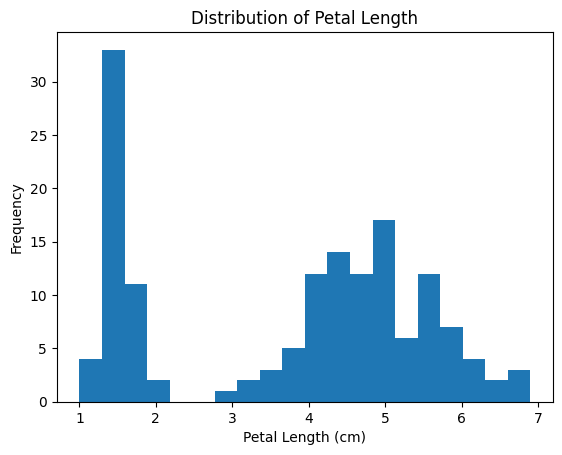

In [15]:
# Histogram of petal length
df["petal_length"].plot(kind="hist", bins=20, title="Distribution of Petal Length")
plt.xlabel("Petal Length (cm)")
plt.show()

### Challenge 15: Scatter matrix of petal dimensions

Create a scatter plot of `petal_length` vs `petal_width`. Do larger petals tend to be longer as well?

> Bonus: use `pd.plotting.scatter_matrix(df)` to see all pairwise relationships at once.

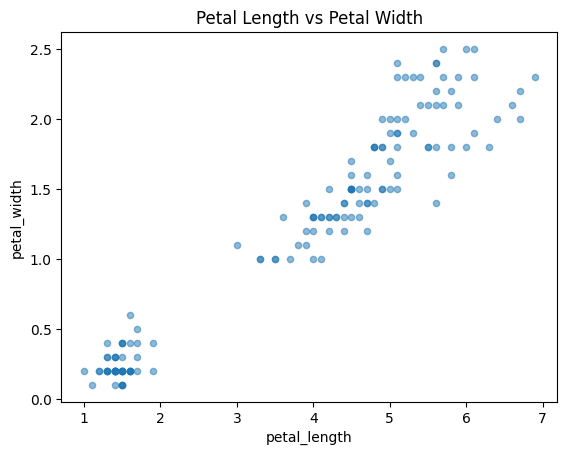

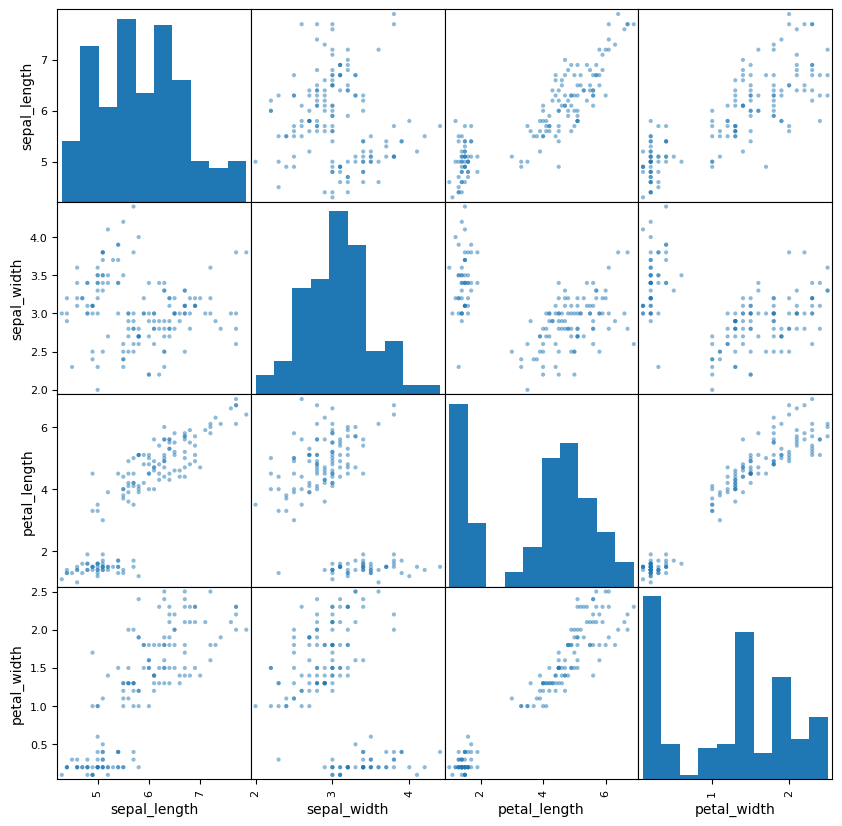

In [16]:
# Scatter: petal length vs petal width
df.plot(
    kind="scatter",
    x="petal_length",
    y="petal_width",
    title="Petal Length vs Petal Width",
    alpha=0.5,
)
plt.show()

# Bonus: all pairwise relationships of the four original measurements
pd.plotting.scatter_matrix(
    df[["sepal_length", "sepal_width", "petal_length", "petal_width"]],
    figsize=(10, 10),
    alpha=0.5,
)
plt.show()